# FlashEats: Class 7 Challenge (solved)
## Model the Business Workflow with Data

### Client question
> **"Show us where in the workflow delay accumulates, how customers react, what interventions we make, and which metrics we should use to improve the project KPI."**

Do not repeat source discovery, retrieval, or data-cleaning work. Today the goal is to build a useful business-workflow model.

> **How to run:** the FlashEats classroom pack is the instructor's material and is not in this repo. Put it in `Code/` at the repo root (so `Code/database/flasheats.db` exists), install `pandas matplotlib`, then run top to bottom. The dispatch data is read from the raw API pages saved by the Class 5 notebook; if those are missing, the API's own data file is used.

In [1]:
import json, sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

# Local run: look in the current folder, then in the repo's Code/ folder
def find_pack_root():
    for candidate in [Path.cwd(), Path.cwd() / "Code", Path.cwd().parent / "Code"]:
        if (candidate / "database" / "flasheats.db").exists():
            return candidate
    return None

BASE = find_pack_root()
if BASE is None: raise FileNotFoundError("FlashEats pack not found. Put it in Code/ at the repo root.")
print("Using pack:", BASE.name)

Using pack: Code


In [2]:
con=sqlite3.connect(BASE/"database"/"flasheats.db")
orders=pd.read_sql("SELECT * FROM orders",con)
customers=pd.read_sql("SELECT * FROM customers",con)
restaurants=pd.read_sql("SELECT * FROM restaurants",con)
drivers=pd.read_sql("SELECT * FROM drivers",con)
tickets=pd.read_csv(BASE/"data"/"support_tickets.csv")
customer_actions=pd.read_csv(BASE/"data"/"customer_app_actions.csv")
interventions=pd.read_csv(BASE/"data"/"order_interventions.csv")
outcomes=pd.read_csv(BASE/"data"/"order_outcomes.csv")
with open(BASE/"data"/"class7_model_brief.json") as f: model_brief=json.load(f)
print("orders",orders.shape,"actions",customer_actions.shape,"interventions",interventions.shape,"outcomes",outcomes.shape)
print("Project KPI:",model_brief["project_kpi"])

orders (1603, 13) actions (2365, 6) interventions (430, 6) outcomes (1600, 6)
Project KPI: Reduce late delivery rate


In [3]:
# Reuse earlier work instead of repeating it:
#  - Class 5: dispatch records from the raw API pages preserved during retrieval
#  - Class 6: one row per order, representation-only label fixes, chronology flags (flag, never delete)
raw_pages = sorted((BASE / "student_output" / "raw_dispatch").glob("dispatch_page_*.json"))
if raw_pages:
    dispatch = pd.DataFrame([r for p in raw_pages for r in json.loads(p.read_text())["data"]])
    print("dispatch: from", len(raw_pages), "raw pages saved in Class 5")
else:
    dispatch = pd.DataFrame(json.loads((BASE / "api" / "dispatch_data.json").read_text()))
    print("dispatch: Class 5 raw pages not found, read the API's data file instead")
assert dispatch["order_id"].is_unique and len(dispatch) == 1600

with open(BASE / "data" / "driver_events.json") as f:
    driver_events = pd.DataFrame([{"driver_id": d["driver_id"], **e} for d in json.load(f) for e in d["events"]])

restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv").drop_duplicates()

def to_time(df, cols):
    for c in cols:
        df[c] = pd.to_datetime(df[c], format="mixed", errors="coerce")
    return df

base = to_time(orders.drop_duplicates("order_id", keep="first").copy(),
               ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"])
base["chronology_violation"] = (base["promised_eta"] < base["created_at"]) | (base["actual_delivery_at"] < base["pickup_at"])
dispatch = to_time(dispatch, ["assigned_at", "reassigned_at"])
driver_events = to_time(driver_events, ["timestamp"])
restaurant_status = to_time(restaurant_status, ["last_updated_at"])
customer_actions = to_time(customer_actions, ["action_at"])
interventions = to_time(interventions, ["intervention_at"])
tickets = to_time(tickets.drop_duplicates("ticket_id", keep="first").copy(), ["created_at"])
tickets["category_norm"] = tickets["category"].str.strip().str.lower()
print("orders:", len(base), "| chronology violators flagged:", int(base["chronology_violation"].sum()))

dispatch: from 16 raw pages saved in Class 5
orders: 1600 | chronology violators flagged: 9


# Challenge 1: Reconstruct the order lifecycle

Choose 3 orders:
- one delivered on time,
- one delivered late,
- one with an intervention.

Build a timeline with:

`event_time | event_type | actor | source_system`

Include as many lifecycle events as the data supports.

### Hint
Start from one `order_id`, collect events from each source, then sort by time.

In [4]:
base_orders=orders.drop_duplicates("order_id",keep="first")
late_order=outcomes[outcomes.late_flag==1].order_id.iloc[0]
on_time_order=outcomes[outcomes.late_flag==0].order_id.iloc[0]
intervention_order=interventions.order_id.iloc[0]
print("late",late_order,"on-time",on_time_order,"intervention",intervention_order)

late O00001 on-time O00003 intervention O00781


In [5]:
def build_order_timeline(order_id):
    rows = []
    o = base.set_index("order_id").loc[order_id]
    rows += [(o.created_at, "ORDER_CREATED", f"customer {o.customer_id}", "orders (SQLite)"),
             (o.promised_eta, "PROMISED_ETA (deadline)", "system", "orders (SQLite)"),
             (o.pickup_at, "PICKED_UP", f"driver {o.driver_id}", "orders (SQLite)"),
             (o.actual_delivery_at, "DELIVERED", f"driver {o.driver_id}", "orders (SQLite)")]
    for d in dispatch[dispatch.order_id == order_id].itertuples():
        rows.append((d.assigned_at, "DRIVER_ASSIGNED", f"driver {d.original_driver_id}", "dispatch API"))
        rows.append((d.reassigned_at, "DRIVER_REASSIGNED", f"driver {d.driver_id}", "dispatch API"))
    for r in restaurant_status[restaurant_status.order_id == order_id].itertuples():
        rows.append((r.last_updated_at, f"RESTAURANT_STATUS: {r.status.strip()}", f"restaurant {r.restaurant_id}",
                     "restaurant_status.csv"))
    for e in driver_events[(driver_events.order_id == order_id) & (driver_events.type == "gps_ping")].itertuples():
        rows.append((e.timestamp, "GPS_PING", f"driver {e.driver_id}", "driver_events.json"))
    for a in customer_actions[customer_actions.order_id == order_id].itertuples():
        rows.append((a.action_at, a.action_type, f"customer {a.customer_id}", "customer_app_actions.csv"))
    for t in tickets[tickets.order_id == order_id].itertuples():
        rows.append((t.created_at, f"TICKET: {t.category_norm}", "customer", "support_tickets.csv"))
    for i in interventions[interventions.order_id == order_id].itertuples():
        rows.append((i.intervention_at, f"INTERVENTION: {i.intervention_type}", i.initiated_by,
                     "order_interventions.csv"))
    timeline = pd.DataFrame(rows, columns=["event_time", "event_type", "actor", "source_system"])
    return timeline.dropna(subset=["event_time"]).sort_values("event_time").reset_index(drop=True)

for label, oid in [("ON TIME", on_time_order), ("LATE", late_order), ("WITH INTERVENTION", intervention_order)]:
    out = outcomes.set_index("order_id").loc[oid]
    print(f"\n{label}: {oid} | {out.outcome_bucket}, delay {out.delay_min:+.1f} min")
    display(build_order_timeline(oid))


ON TIME: O00003 | delivered_on_time, delay -4.4 min


,event_time,event_type,actor,source_system
0,2026-08-01 19:35:00.000000,ORDER_CREATED,customer C0855,orders (SQLite)
1,2026-08-01 19:35:00.002443,DRIVER_ASSIGNED,driver D039,dispatch API
2,2026-08-01 19:44:37.017130,GPS_PING,driver D039,driver_events.json
3,2026-08-01 19:48:00.000000,RESTAURANT_STATUS: preparing,restaurant R010,restaurant_status.csv
4,2026-08-01 19:54:14.031817,GPS_PING,driver D039,driver_events.json
5,2026-08-01 19:57:50.820366,PICKED_UP,driver D039,orders (SQLite)
6,2026-08-01 20:03:51.046504,GPS_PING,driver D039,driver_events.json
7,2026-08-01 20:13:28.061191,DELIVERED,driver D039,orders (SQLite)
8,2026-08-01 20:17:52.941967,PROMISED_ETA (deadline),system,orders (SQLite)



LATE: O00001 | delivered_late, delay +10.8 min


,event_time,event_type,actor,source_system
0,2026-08-13 12:56:00.000000,ORDER_CREATED,customer C0168,orders (SQLite)
1,2026-08-13 13:01:09.659644,DRIVER_ASSIGNED,driver D103,dispatch API
2,2026-08-13 13:08:00.000000,INTERVENTION: DRIVER_REASSIGNMENT,dispatch,order_interventions.csv
3,2026-08-13 13:14:42.222353,GPS_PING,driver D103,driver_events.json
4,2026-08-13 13:21:00.000000,ETA_VIEWED,customer C0168,customer_app_actions.csv
5,2026-08-13 13:28:14.785062,GPS_PING,driver D103,driver_events.json
6,2026-08-13 13:35:49.825561,PICKED_UP,driver D103,orders (SQLite)
7,2026-08-13 13:41:47.347771,GPS_PING,driver D103,driver_events.json
8,2026-08-13 13:55:19.910481,GPS_PING,driver D103,driver_events.json
9,2026-08-13 14:08:52.473190,GPS_PING,driver D103,driver_events.json



WITH INTERVENTION: O00781 | delivered_late, delay +13.1 min


,event_time,event_type,actor,source_system
0,2026-08-22 12:33:00.000000,ORDER_CREATED,customer C0103,orders (SQLite)
1,2026-08-22 12:40:42.931820,DRIVER_ASSIGNED,driver D103,dispatch API
2,2026-08-22 12:54:00.000000,ETA_VIEWED,customer C0103,customer_app_actions.csv
3,2026-08-22 12:57:00.000000,INTERVENTION: PRIORITY_DISPATCH,operations,order_interventions.csv
4,2026-08-22 13:04:00.000000,RESTAURANT_STATUS: ready,restaurant R019,restaurant_status.csv
5,2026-08-22 13:07:42.051142,GPS_PING,driver D103,driver_events.json
6,2026-08-22 13:11:17.309762,PICKED_UP,driver D103,orders (SQLite)
7,2026-08-22 13:22:41.170463,GPS_PING,driver D103,driver_events.json
8,2026-08-22 13:48:36.000000,PROMISED_ETA (deadline),system,orders (SQLite)
9,2026-08-22 14:01:40.289785,DELIVERED,driver D103,orders (SQLite)


**Challenge 1 answer.** Seven sources contribute to one order's story: the orders table, dispatch, driver GPS, restaurant status, the customer app, support tickets and interventions.

- **O00003 (on time, 4.4 min early):** created and a driver assigned at once, restaurant `preparing`, picked up, delivered before the deadline. No customer, support or intervention activity.
- **O00001 (late, 10.8 min):** a `DRIVER_REASSIGNMENT` intervention 12 minutes in, pickup, the promised ETA passes, then the customer opens support in the app, then delivery. The dispatch API shows **no** reassignment for this order: the sources disagree.
- **O00781 (late, 13.1 min, with intervention):** a `PRIORITY_DISPATCH` early in the order, restaurant `ready`, pickup, delivery 13 minutes after the promise.

The timeline shows *what* happened, but no source records *why* the pickup took as long as it did: there is no "driver arrived at restaurant" event.

# Challenge 2: Define the canonical project model

Your model must support:
1. customer → orders
2. order → customer interactions
3. order → support interactions
4. order → interventions
5. order → outcome

For each table, document:
- primary key,
- important foreign keys,
- grain.

Then explain why this model is better for the project than mirroring every source-system table.

In [6]:
sources={"orders":orders,"customer_actions":customer_actions,"support_tickets":tickets,"interventions":interventions,"outcomes":outcomes}
for name,df in sources.items():
    print(name,df.shape); display(df.head(2))

orders (1603, 13)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear


customer_actions (2365, 6)


,action_id,order_id,customer_id,action_type,action_at,channel
0,ACT-00001,O01044,C0249,ETA_VIEWED,2026-08-05 22:11:00,mobile_app
1,ACT-00002,O01334,C0692,ETA_VIEWED,2026-08-01 17:48:00,mobile_app


support_tickets (201, 6)


,ticket_id,order_id,created_at,category,customer_message,category_norm
0,T00001,NaN,2026-08-26 23:34:00,late_delivery,My order is already past the promised time.,late_delivery
1,T00002,NaN,2026-08-24 13:49:00,eta_changed,The ETA keeps changing and the food is still not here.,eta_changed


interventions (430, 6)


,intervention_id,order_id,intervention_type,intervention_at,initiated_by,reason
0,INT-00001,O00781,PRIORITY_DISPATCH,2026-08-22 12:57:00.000000,operations,late_risk
1,INT-00002,O01476,CUSTOMER_CREDIT,2026-08-01 23:46:36.200640,support,support_resolution


outcomes (1600, 6)


,order_id,final_status_norm,delivered_flag,late_flag,delay_min,outcome_bucket
0,O00001,delivered,1,1.0,10.82,delivered_late
1,O00002,delivered,1,1.0,3.97,delivered_late


In [7]:
# Check the proposed keys against the data before writing them down
model_tables = [
    ("customer", customers, "customer_id", [], "one customer"),
    ("restaurant", restaurants, "restaurant_id", [], "one restaurant"),
    ("driver", drivers, "driver_id", [], "one driver"),
    ("order", orders, "order_id", ["customer_id", "restaurant_id", "driver_id"], "one order"),
    ("outcome", outcomes, "order_id", ["order_id"], "one order (1 to 1 with order)"),
    ("customer_action", customer_actions, "action_id", ["order_id", "customer_id"], "one app action"),
    ("support_ticket", tickets, "ticket_id", ["order_id"], "one ticket"),
    ("intervention", interventions, "intervention_id", ["order_id"], "one operations action"),
]
order_ids = set(base["order_id"])
pd.DataFrame([{
    "table": name, "rows": len(df), "primary key": pk, "PK unique": df[pk].is_unique,
    "foreign keys": ", ".join(fks) or "none", "grain": grain,
    "order_id maps to order": (f"{df['order_id'].dropna().isin(order_ids).mean():.0%} "
                               f"({int(df['order_id'].isna().sum())} null)") if "order_id" in fks else "",
} for name, df, pk, fks, grain in model_tables])

,table,rows,primary key,PK unique,foreign keys,grain,order_id maps to order
0,customer,900,customer_id,True,none,one customer,
1,restaurant,60,restaurant_id,True,none,one restaurant,
2,driver,120,driver_id,True,none,one driver,
3,order,1603,order_id,False,"customer_id, restaurant_id, driver_id",one order,
4,outcome,1600,order_id,True,order_id,one order (1 to 1 with order),100% (0 null)
5,customer_action,2365,action_id,True,"order_id, customer_id",one app action,100% (0 null)
6,support_ticket,201,ticket_id,True,order_id,one ticket,100% (3 null)
7,intervention,430,intervention_id,True,order_id,one operations action,100% (0 null)


In [8]:
# Cardinality of each order-level relationship in this data
pd.DataFrame([
    {"relationship": "customer → orders", "max per parent": int(base.groupby("customer_id").size().max())},
    {"relationship": "order → customer actions", "max per parent": int(customer_actions.groupby("order_id").size().max())},
    {"relationship": "order → support tickets", "max per parent": int(tickets.groupby("order_id").size().max())},
    {"relationship": "order → interventions", "max per parent": int(interventions.groupby("order_id").size().max())},
    {"relationship": "order → outcome", "max per parent": int(outcomes.groupby("order_id").size().max())},
])

,relationship,max per parent
0,customer → orders,8
1,order → customer actions,5
2,order → support tickets,1
3,order → interventions,1
4,order → outcome,1


**Challenge 2 answer.** Everything hangs off the **order**, joined by `order_id`:

```
customer 1 ──< order >── 1 restaurant
                 │  >── 1 driver
                 ├── 1 outcome              (late_flag, delay_min, outcome_bucket)
                 ├──< customer_action       (ETA_VIEWED, SUPPORT_OPENED, CANCEL_ATTEMPTED)
                 ├──< support_ticket
                 └──< intervention          (reassignment, restaurant contact, priority dispatch, credit)
```

| Table | Primary key | Foreign keys | Grain |
|---|---|---|---|
| customer / restaurant / driver | `customer_id` / `restaurant_id` / `driver_id` | none | one customer / restaurant / driver |
| **order** | `order_id` | `customer_id`, `restaurant_id`, `driver_id` | one order (after keeping one row per order) |
| **outcome** | `order_id` | `order_id` | one order, 1 to 1 |
| customer_action | `action_id` | `order_id`, `customer_id` | one app action |
| support_ticket | `ticket_id` | `order_id` (3 null) | one ticket (after removing the duplicate `T00013`) |
| intervention | `intervention_id` | `order_id` | one intervention (1 per order today, many allowed by design) |

**Why this beats mirroring every source table:**
- **The order is the unit of the KPI.** Late delivery rate is per order, so every question starts from the order instead of joining eight differently shaped tables.
- **One grain per table**, so "aggregate the many side, then join" is always obvious (Challenge 3).
- **Fewer, agreed tables mean fewer conflicts.** `customer_interactions.csv` and `order_events.csv` restate support contacts and interventions but disagree with the dedicated tables, so they are left out rather than importing their contradictions.
- **Stable when systems change.** If the app or dispatch system is replaced, only the source-to-table mapping changes, not the business questions.

# Challenge 3: Build interaction → intervention → outcome

Create one order-level table containing:

`order_id, customer_id, support_opened, cancel_attempted, intervention_count, intervention_types, final_status, late_flag, delay_min`

Answer:
1. How many late orders had support interaction?
2. How many orders received intervention?
3. Which intervention is most common?
4. Which frustrated journeys had no intervention?

### Hint
Aggregate one-to-many tables before joining them to order-level outcomes.

In [9]:
# Why aggregate first: a naive join repeats each order once per matching row
naive = outcomes.merge(interventions, on="order_id", how="left").merge(customer_actions, on="order_id", how="left")
print(f"Naive join: {len(naive)} rows for {naive['order_id'].nunique()} orders")

Naive join: 2865 rows for 1600 orders


In [10]:
actions_by_order = (customer_actions
    .assign(eta_viewed=customer_actions.action_type.eq("ETA_VIEWED"),
            support_opened=customer_actions.action_type.eq("SUPPORT_OPENED"),
            cancel_attempted=customer_actions.action_type.eq("CANCEL_ATTEMPTED"))
    .groupby("order_id")
    .agg(action_count=("action_id", "count"), eta_views=("eta_viewed", "sum"),
         support_opened=("support_opened", "max"), cancel_attempted=("cancel_attempted", "max"))
    .reset_index())
first_support_opened = (customer_actions[customer_actions.action_type == "SUPPORT_OPENED"]
    .groupby("order_id")["action_at"].min().rename("first_support_opened_at").reset_index())

interventions_by_order = (interventions.groupby("order_id")
    .agg(intervention_count=("intervention_id", "count"),
         intervention_types=("intervention_type", lambda s: ", ".join(sorted(s))),
         first_intervention_at=("intervention_at", "min"))
    .reset_index())

tickets_by_order = (tickets.dropna(subset=["order_id"]).groupby("order_id")
    .agg(ticket_count=("ticket_id", "count"), first_ticket_at=("created_at", "min"))
    .reset_index())

order_model = (outcomes
    .merge(base[["order_id", "customer_id", "restaurant_id", "driver_id", "created_at", "promised_eta",
                 "pickup_at", "actual_delivery_at", "chronology_violation"]], on="order_id", how="left")
    .merge(dispatch[["order_id", "assigned_at", "reassigned_at"]], on="order_id", how="left")
    .merge(actions_by_order, on="order_id", how="left")
    .merge(first_support_opened, on="order_id", how="left")
    .merge(interventions_by_order, on="order_id", how="left")
    .merge(tickets_by_order, on="order_id", how="left"))

for c in ["action_count", "eta_views", "intervention_count", "ticket_count"]:
    order_model[c] = order_model[c].fillna(0).astype(int)
for c in ["support_opened", "cancel_attempted"]:
    order_model[c] = order_model[c].astype("boolean").fillna(False).astype(bool)
order_model["intervention_types"] = order_model["intervention_types"].fillna("")
order_model["has_ticket"] = order_model["ticket_count"] > 0
order_model["has_intervention"] = order_model["intervention_count"] > 0
order_model["support_contact"] = order_model["support_opened"] | order_model["has_ticket"]
order_model = order_model.rename(columns={"final_status_norm": "final_status"})

print("Rows:", len(order_model), "| unique orders:", order_model["order_id"].nunique())
order_model[["order_id", "customer_id", "support_opened", "cancel_attempted", "intervention_count",
             "intervention_types", "final_status", "late_flag", "delay_min"]].head()

Rows: 1600 | unique orders: 1600


,order_id,customer_id,support_opened,cancel_attempted,intervention_count,intervention_types,final_status,late_flag,delay_min
0,O00001,C0168,True,False,1,DRIVER_REASSIGNMENT,delivered,1.0,10.82
1,O00002,C0043,False,False,0,,delivered,1.0,3.97
2,O00003,C0855,False,False,0,,delivered,0.0,-4.41
3,O00004,C0229,False,False,0,,cancelled,NaN,NaN
4,O00005,C0040,False,False,0,,delivered,1.0,21.02


In [11]:
known = order_model[order_model["late_flag"].notna()]            # 1,495 orders with a known outcome
late = known[known["late_flag"] == 1]

# "Support interaction" is recorded in three places that disagree, so report each one
interactions = pd.read_csv(BASE / "data" / "customer_interactions.csv")
ticket_interaction_orders = set(interactions.loc[interactions["interaction_type"] == "SUPPORT_TICKET", "order_id"])
support_sources = {
    "SUPPORT_OPENED app action": late["support_opened"],
    "support ticket (tickets file)": late["has_ticket"],
    "SUPPORT_TICKET (customer_interactions.csv)": late["order_id"].isin(ticket_interaction_orders),
}
support_sources["any of the three"] = pd.concat(support_sources.values(), axis=1).any(axis=1)
display(pd.DataFrame([{"support source": k, "late orders with support": int(v.sum()),
                       "share of late orders": f"{v.mean():.1%}"} for k, v in support_sources.items()]))

print("Orders that received an intervention:", int(order_model["has_intervention"].sum()), "of", len(order_model))
display(interventions["intervention_type"].value_counts().to_frame("interventions"))

,support source,late orders with support,share of late orders
0,SUPPORT_OPENED app action,138,16.4%
1,support ticket (tickets file),163,19.3%
2,SUPPORT_TICKET (customer_interactions.csv),146,17.3%
3,any of the three,258,30.6%


Orders that received an intervention: 430 of 1600


,interventions
intervention_type,
DRIVER_REASSIGNMENT,155
RESTAURANT_CONTACT,116
PRIORITY_DISPATCH,95
CUSTOMER_CREDIT,64


In [12]:
# Frustrated journey: the customer opened support, tried to cancel, or raised a ticket
order_model["frustrated"] = order_model["support_opened"] | order_model["cancel_attempted"] | order_model["has_ticket"]
frustrated = order_model[order_model["frustrated"]]
no_help = frustrated[~frustrated["has_intervention"]]
print(f"Frustrated journeys: {len(frustrated)} | with no intervention: {len(no_help)} ({len(no_help) / len(frustrated):.1%}) "
      f"| of those, late: {int((no_help['late_flag'] == 1).sum())}")
display(no_help.sort_values("delay_min", ascending=False)[
    ["order_id", "support_opened", "cancel_attempted", "ticket_count", "outcome_bucket", "delay_min"]].head(10))

Frustrated journeys: 294 | with no intervention: 219 (74.5%) | of those, late: 192


,order_id,support_opened,cancel_attempted,ticket_count,outcome_bucket,delay_min
193,O00194,False,False,1,delivered_late,38.34
736,O00737,True,False,0,delivered_late,36.28
302,O00303,False,False,1,delivered_late,33.16
210,O00211,True,False,1,delivered_late,32.38
1234,O01235,False,False,1,delivered_late,32.00
976,O00977,True,False,1,delivered_late,31.92
994,O00995,True,False,1,delivered_late,31.72
1196,O01197,False,False,1,delivered_late,31.61
892,O00893,True,False,0,delivered_late,30.32
1143,O01144,True,False,1,delivered_late,30.13


**Challenge 3 answer.** The order-level table has **1,600 rows, one per order**; the naive join would have given 2,865.

1. **Late orders with support interaction:** it depends on which source defines "support": 138 (app button), 146 (interactions file) or 163 (tickets) of 843 late orders, and 258 (30.6%) using any of the three. The three sources overlap poorly, so the business must agree one definition.
2. **Orders that received an intervention:** 430 of 1,600 (26.9%).
3. **Most common intervention:** `DRIVER_REASSIGNMENT` (155), then restaurant contact (116), priority dispatch (95) and customer credit (64).
4. **Frustrated journeys with no intervention:** 219 of 294 (74.5%), and 192 of them ended late. These customers asked for help and operations never acted.

# Challenge 4: Select 3 to 5 business metrics

Project KPI: **Reduce Late Delivery Rate**.

For each chosen metric, document:
- metric name,
- formula,
- grain,
- why it matters,
- relationship to the project KPI.

At least one metric must represent:
- an outcome,
- a customer interaction,
- an intervention.

In [13]:
# Stage durations, on orders with a known outcome and valid chronology
stages = known[~known["chronology_violation"]].copy()
stages["created_to_assigned_min"] = (stages["assigned_at"] - stages["created_at"]).dt.total_seconds() / 60
stages["assigned_to_pickup_min"] = (stages["pickup_at"] - stages["assigned_at"]).dt.total_seconds() / 60
stages["pickup_to_delivered_min"] = (stages["actual_delivery_at"] - stages["pickup_at"]).dt.total_seconds() / 60
stages["promised_window_min"] = (stages["promised_eta"] - stages["created_at"]).dt.total_seconds() / 60
stage_cols = ["created_to_assigned_min", "assigned_to_pickup_min", "pickup_to_delivered_min", "promised_window_min"]

stage_view = stages.groupby("outcome_bucket")[stage_cols].mean().T.round(1)
stage_view["extra on late orders"] = (stage_view["delivered_late"] - stage_view["delivered_on_time"]).round(1)
stage_view["correlation with delay"] = [round(stages[c].corr(stages["delay_min"]), 2) for c in stage_cols]
stage_view

outcome_bucket,delivered_late,delivered_on_time,extra on late orders,correlation with delay
created_to_assigned_min,3.4,3.5,-0.1,-0.03
assigned_to_pickup_min,30.3,16.0,14.3,0.89
pickup_to_delivered_min,47.7,43.4,4.3,0.23
promised_window_min,71.2,69.3,1.9,0.13


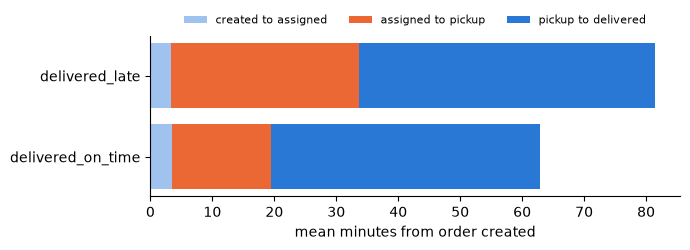

In [14]:
fig, ax = plt.subplots(figsize=(7, 2.6))
view = stage_view.loc[stage_cols[:3], ["delivered_on_time", "delivered_late"]].T
left = pd.Series(0.0, index=view.index)
for col, color in zip(stage_cols[:3], ["#9fc3ee", "#eb6834", "#2a78d6"]):
    ax.barh(view.index, view[col], left=left, color=color, label=col.replace("_min", "").replace("_", " "))
    left += view[col]
ax.set_xlabel("mean minutes from order created"); ax.legend(frameon=False, fontsize=8, ncol=3, loc="lower center",
                                                             bbox_to_anchor=(0.5, 1.0))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [15]:
early_ticket = order_model["first_ticket_at"] < order_model["pickup_at"]
metrics = pd.DataFrame([
    {"metric": "M1 Late delivery rate", "type": "Outcome (the KPI)",
     "formula": "late orders / orders with a known delivery time", "grain": "order",
     "value": f"{known['late_flag'].mean():.1%} ({int(known['late_flag'].sum())} of {len(known)})"},
    {"metric": "M2 Assigned-to-pickup minutes", "type": "Workflow driver",
     "formula": "mean(pickup_at - assigned_at)", "grain": "order",
     "value": f"late {stage_view.loc['assigned_to_pickup_min', 'delivered_late']} vs "
              f"on time {stage_view.loc['assigned_to_pickup_min', 'delivered_on_time']} min"},
    {"metric": "M3 Early-ticket rate", "type": "Customer interaction",
     "formula": "orders with a ticket raised before pickup / orders", "grain": "order",
     "value": f"{int(early_ticket.sum())} orders ({early_ticket.mean():.1%}); "
              f"{(order_model.loc[early_ticket & order_model['late_flag'].notna(), 'late_flag'] == 1).mean():.1%} end late"},
    {"metric": "M4 Late-order intervention coverage", "type": "Intervention",
     "formula": "late orders with an intervention / late orders", "grain": "order",
     "value": f"{late['has_intervention'].mean():.1%} ({int(late['has_intervention'].sum())} of {len(late)})"},
    {"metric": "M5 Promised-window padding", "type": "Workflow driver (ETA)",
     "formula": "mean(promised_eta - created_at)", "grain": "order",
     "value": f"late {stage_view.loc['promised_window_min', 'delivered_late']} vs "
              f"on time {stage_view.loc['promised_window_min', 'delivered_on_time']} min"},
])
metrics

,metric,type,formula,grain,value
0,M1 Late delivery rate,Outcome (the KPI),late orders / orders with a known delivery time,order,56.4% (843 of 1495)
1,M2 Assigned-to-pickup minutes,Workflow driver,mean(pickup_at - assigned_at),order,late 30.3 vs on time 16.0 min
2,M3 Early-ticket rate,Customer interaction,orders with a ticket raised before pickup / orders,order,95 orders (5.9%); 97.9% end late
3,M4 Late-order intervention coverage,Intervention,late orders with an intervention / late orders,order,27.0% (228 of 843)
4,M5 Promised-window padding,Workflow driver (ETA),mean(promised_eta - created_at),order,late 71.2 vs on time 69.3 min


**Challenge 4 answer.**

| Metric | Type | Why it matters | Link to the KPI |
|---|---|---|---|
| **M1 Late delivery rate** | Outcome | The KPI itself: 56.4% of 1,495 orders with a known delivery time | Is the number we want to move. Needs the Class 6 caveat: one written definition and an owner |
| **M2 Assigned-to-pickup minutes** | Workflow driver | Late orders spend about 14 minutes longer here, most of the gap, and operations can act on it | Shorter pickup waits should lower the late rate |
| **M3 Early-ticket rate** | Customer interaction | A ticket raised *before pickup* ends late almost every time, with about an hour of warning left | An early trigger for action on at-risk orders |
| **M4 Late-order intervention coverage** | Intervention | Only about 1 in 4 late orders was touched by operations | Measures whether at-risk orders get help; it is coverage, not effectiveness |
| **M5 Promised-window padding** | Workflow driver (ETA) | The promise is barely longer for orders that end up late | Shows the ETA does not price in pickup risk, which inflates the late rate |

Deliberately **not** chosen: "late rate with vs without intervention" (it cannot show an effect in this data, see Challenge 5B) and `SUPPORT_OPENED` counts (the app button is pressed *after* the promise is already broken, so it is a trailing signal).

# Challenge 5: Investigate the workflow with joins and aggregations

Answer at least three:

A. Do orders with support interactions have higher delay?
B. What is late rate with vs without intervention?
C. Which intervention type is associated with the lowest late rate?
D. Which restaurants contribute the largest number of late orders?
E. Which journeys show support interaction + intervention + still late?

For every answer, add one sentence:

> **What does this tell the business, and what does it NOT prove?**

In [16]:
def late_view(group_col, data=known):
    return data.groupby(group_col).agg(orders=("order_id", "count"), late_rate=("late_flag", "mean"),
                                       median_delay_min=("delay_min", "median")).round(3)

print("A. Support contact (app button or ticket)")
display(late_view("support_contact"))
print("B. Any intervention")
display(late_view("has_intervention"))
print("C. By intervention type (orders with exactly one intervention)")
display(late_view("intervention_types", known[known["has_intervention"]]).sort_values("late_rate"))

A. Support contact (app button or ticket)


,orders,late_rate,median_delay_min
support_contact,,,
False,1203,0.486,-0.250
True,292,0.884,12.285


B. Any intervention


,orders,late_rate,median_delay_min
has_intervention,,,
False,1091,0.564,1.39
True,404,0.564,1.54


C. By intervention type (orders with exactly one intervention)


,orders,late_rate,median_delay_min
intervention_types,,,
PRIORITY_DISPATCH,86,0.512,0.33
RESTAURANT_CONTACT,108,0.528,0.80
DRIVER_REASSIGNMENT,147,0.578,1.60
CUSTOMER_CREDIT,63,0.667,2.93


In [17]:
# When does each signal happen, relative to the promised ETA? A signal after the promise cannot prevent lateness.
def minutes_vs_promise(times):
    return ((times - order_model["promised_eta"]).dt.total_seconds() / 60).median()

signals = pd.Series({
    "support ticket created (first)": minutes_vs_promise(order_model["first_ticket_at"]),
    "SUPPORT_OPENED in app (first)": minutes_vs_promise(order_model["first_support_opened_at"]),
    "intervention (first)": minutes_vs_promise(order_model["first_intervention_at"]),
}).round(1)
display(signals.rename("median minutes vs promised ETA (negative = before)").to_frame())

timing = interventions.merge(base[["order_id", "promised_eta"]], on="order_id")
timing["min_vs_promise"] = (timing["intervention_at"] - timing["promised_eta"]).dt.total_seconds() / 60
display(timing.groupby("intervention_type")["min_vs_promise"].median().round(1).rename("median min vs promised ETA").to_frame())

,median minutes vs promised ETA (negative = before)
support ticket created (first),-35.2
SUPPORT_OPENED in app (first),11.0
intervention (first),-48.6


,median min vs promised ETA
intervention_type,
CUSTOMER_CREDIT,11.5
DRIVER_REASSIGNMENT,-54.6
PRIORITY_DISPATCH,-50.5
RESTAURANT_CONTACT,-47.6


In [18]:
print("D. Restaurants with the most late orders")
by_restaurant = known.groupby("restaurant_id").agg(orders=("order_id", "count"), late_orders=("late_flag", "sum"),
                                                   late_rate=("late_flag", "mean")).sort_values("late_orders", ascending=False)
display(by_restaurant.head(6).round(2))
top5_share = by_restaurant["late_orders"].head(5).sum() / by_restaurant["late_orders"].sum()
print(f"Restaurants: {len(by_restaurant)} | median orders each: {by_restaurant['orders'].median():.0f} | "
      f"top 5 share of all late orders: {top5_share:.1%}")

print("\nE. Support contact + intervention + still late")
still_late = known[known["support_contact"] & known["has_intervention"] & (known["late_flag"] == 1)]
print(f"{len(still_late)} journeys | median delay {still_late['delay_min'].median():.1f} min | "
      f"more than 15 min late: {int((still_late['delay_min'] > 15).sum())}")
display(still_late.sort_values("delay_min", ascending=False)[
    ["order_id", "intervention_types", "ticket_count", "support_opened", "delay_min", "chronology_violation"]].head(8))

D. Restaurants with the most late orders


,orders,late_orders,late_rate
restaurant_id,,,
R050,35,22.0,0.63
R004,30,20.0,0.67
R024,25,20.0,0.80
R023,32,20.0,0.62
R030,38,20.0,0.53
R051,29,20.0,0.69


Restaurants: 60 | median orders each: 25 | top 5 share of all late orders: 12.1%

E. Support contact + intervention + still late
67 journeys | median delay 13.7 min | more than 15 min late: 32


,order_id,intervention_types,ticket_count,support_opened,delay_min,chronology_violation
100,O00101,CUSTOMER_CREDIT,0,True,85.51,True
197,O00198,RESTAURANT_CONTACT,1,False,35.23,False
496,O00497,PRIORITY_DISPATCH,1,False,31.78,False
612,O00613,PRIORITY_DISPATCH,1,False,27.18,False
7,O00008,CUSTOMER_CREDIT,0,True,26.86,False
301,O00302,PRIORITY_DISPATCH,1,True,26.32,False
543,O00544,DRIVER_REASSIGNMENT,1,False,24.92,False
861,O00862,DRIVER_REASSIGNMENT,1,True,24.10,False


**Challenge 5 answer.** Reminder: association is not causation.

**A. Do orders with support interactions have higher delay?** Yes, strongly: about 88% late with support contact vs about 49% without, with a median delay of about +12 minutes vs about 0.
*Tells the business:* support contact tracks real lateness. *Does NOT prove:* that contacting support causes delay or that support could prevent it; most contact is a *result* of lateness.

**B. Late rate with vs without an intervention?** The same, 56.4% vs 56.4%.
*Tells the business:* interventions are spread evenly over orders that end late and orders that end on time, so they are not being aimed at at-risk orders. *Does NOT prove:* that interventions do not work; without targeting or a fair comparison group this data cannot measure their effect.

**C. Which intervention type has the lowest late rate?** Priority dispatch and restaurant contact are lowest (about 51% and 53%), customer credit is highest (about 67%).
*Tells the business:* no type clearly stands out; groups of 63 to 147 orders are small. *Does NOT prove:* that priority dispatch works best, or that credit hurts: credit is given about 11 minutes *after* the promise, *because* the order is already late (reverse causality).

**D. Which restaurants contribute the most late orders?** The top restaurants each have about 20 late orders, and the top five are only about 12% of all late orders.
*Tells the business:* lateness is spread across the restaurant base, so a "fix the worst restaurants" plan misses most of it. *Does NOT prove:* that any restaurant is better or worse; with about 25 orders each, their rates are mostly noise.

**E. Support contact + intervention + still late:** 67 journeys, median 13.7 minutes late, 32 of them more than 15 minutes late. The top one, O00101, is a Class 6 chronology violator (promised before it was created), so its 85 minute "delay" is a data error, not a real case.
*Tells the business:* this is the list to review case by case. *Does NOT prove:* that those interventions failed; some orders might have been later still without them.

# Challenge 6: Connect the model to the KPI

Create a one-page project view:

`PROJECT KPI → OUTCOME METRIC → WORKFLOW/DRIVER METRICS → INTERVENTIONS → DATA SOURCES/EVENTS`

Answer:
1. Which metrics are directly controllable by operations?
2. Which are outcomes?
3. Which missing event limits the model most?
4. What would you instrument next?

Final deliverable:
- core entities,
- key events,
- relationships,
- 3 to 5 metrics,
- KPI linkage,
- one modelling limitation.

**One-page project view**

| Layer | Content |
|---|---|
| **PROJECT KPI** | Reduce the late delivery rate |
| **OUTCOME METRIC** | M1 late delivery rate: 56.4% (843 of 1,495), owner and definition still to be agreed |
| **WORKFLOW / DRIVER METRICS** | M2 assigned-to-pickup minutes (where late orders lose about 14 min); M5 promised-window padding (the ETA does not reflect pickup risk); M3 early-ticket rate (warning while the order can still be saved) |
| **INTERVENTIONS** | Driver reassignment, restaurant contact, priority dispatch (made early), customer credit (made after the promise, compensation only); M4 late-order intervention coverage |
| **DATA SOURCES / EVENTS** | orders (created, promised, picked up, delivered), dispatch API (assigned, reassigned), app actions, support tickets, interventions, outcomes |

**Answers**
1. **Directly controllable by operations:** assigned-to-pickup time (dispatch and restaurant management), whether and when to reassign, contact the restaurant or prioritise, intervention coverage, and how the promised ETA is set.
2. **Outcomes:** late delivery rate, minutes late, cancellations. We watch these; operations does not set them directly.
3. **The missing event that limits the model most:** **driver arrived at the restaurant** (plus a restaurant `ready` history). The assigned-to-pickup stage holds most of the late-vs-on-time gap, and without that event we cannot say whether the kitchen or the driver caused it.
4. **Instrument next:** a `driver_arrived_at_restaurant` event and a `restaurant_ready_at` history; a `ticket_id` and a resolved time on every intervention, so an intervention can be tied to what triggered it; one agreed source for "support contact" and for "driver reassignment".

**Final deliverable**
- **Core entities:** customer, order, restaurant, driver, support ticket, plus the order outcome.
- **Key events:** order created, driver assigned, picked up, delivered, ticket raised, intervention, customer credit.
- **Relationships:** customer 1 to N orders; order 1 to 1 outcome; order 1 to N app actions, tickets and interventions, all joined on `order_id`.
- **Metrics:** M1 to M5 above.
- **KPI linkage:** the table above.
- **One modelling limitation:** the pickup stage cannot be split between restaurant and driver, and the intervention data cannot show whether interventions work (no targeting, no comparison group, and reassignments that the dispatch system mostly does not confirm).

# Final reflection

A strong solution does not produce the largest schema.

It produces the **smallest useful model that explains the workflow and supports the project KPI**.